# Privacy Policy Risk Analyzer
## Text Mining and NLP Pipeline

---

### What This Tool Does

You provide one or more privacy policy `.txt` files. This system automatically:

1. Cleans and normalizes the text
2. Extracts features using TF-IDF — no hardcoded vocabulary
3. Labels every clause into a privacy category using stemmed keyword matching
4. Trains a **Multinomial Naive Bayes** classifier as the baseline model
5. Compares MNB against Complement NB, Logistic Regression, and Linear SVC — auto-selects the best
6. Scores each document and the full corpus for privacy risk (**HIGH / MEDIUM / LOW**)
7. Surfaces the most important privacy clauses ranked by TF-IDF score
8. Generates a WordCloud, category bar charts, and readability stats
9. Lets you search clauses using keyword and Boolean queries (**AND**, **OR**, **NOT**)

---

### How to Use

1. Place your `.txt` privacy policy files in the same folder as this notebook
2. Update the `files` list in **Step 2** with your filenames
3. Run all cells top to bottom — everything is automatic

---

**Pipeline overview:**

```
Load → Preprocess → TF-IDF → Label → Multinomial NB (baseline)
     → Model Comparison (CNB / LR / SVC) → Auto-select Best
     → Inverted Index → Search → Boolean Retrieval (AND / OR / NOT)
     → Risk Score → Visualize → Evaluate → HTML Report
```


## Step 1 — Import Libraries

All dependencies for this notebook:

| Library | Purpose |
|---|---|
| `nltk` | Sentence tokenization, word tokenization, stopword removal, Porter stemming |
| `sklearn` | TF-IDF vectorization, Naive Bayes (Multinomial + Complement), Logistic Regression, Linear SVC, train/test split, cross-validation, evaluation metrics |
| `wordcloud` | WordCloud visualization |
| `matplotlib` | Bar charts and plots |
| `pandas / numpy` | Data handling and matrix operations |


In [ ]:
import pandas as pd
import numpy as np
import nltk
import warnings
warnings.filterwarnings('ignore')

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from wordcloud import WordCloud
from collections import defaultdict
import matplotlib.pyplot as plt

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print('All libraries loaded.')


## Optional — Convert PDF to TXT

If your privacy policy is in PDF format, convert it to plain text first.

Install the library:
```
pip install pdfplumber
```

Then uncomment and run the cell below.

In [2]:
"""
import pdfplumber

def convert_pdf_to_txt(pdf_path, txt_path):
    with pdfplumber.open(pdf_path) as pdf:
        with open(txt_path, "w", encoding="utf-8") as f:
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    f.write(text + "\n")

# convert_pdf_to_txt("my_policy.pdf", "my_policy.txt")
"""

'\nimport pdfplumber\n\ndef convert_pdf_to_txt(pdf_path, txt_path):\n    with pdfplumber.open(pdf_path) as pdf:\n        with open(txt_path, "w", encoding="utf-8") as f:\n            for page in pdf.pages:\n                text = page.extract_text()\n                if text:\n                    f.write(text + "\n")\n\n# convert_pdf_to_txt("my_policy.pdf", "my_policy.txt")\n'

## Step 2 — Load Privacy Policy Documents

Add the filenames of your `.txt` privacy policy files to the `files` list below.

The system will:
- Read each file
- Split it into individual sentences using NLTK's sentence tokenizer
- Track which file each sentence came from

> Every sentence is treated as one **clause** — the atomic unit of analysis throughout this notebook.

In [3]:
import re

# Add your .txt filenames here
files = [
    "google_policy.txt",
    "amazon_policy.txt",
    "instagram_policy.txt"
]

sentences = []
sources   = []

for file in files:
    with open(file, "r", encoding="utf-8") as f:
        text = f.read()
    # Normalise: replace newlines with space, collapse multiple spaces
    text = text.replace('\n', ' ')
    text = re.sub(r' {2,}', ' ', text)
    sents = sent_tokenize(text)
    # Normalise each sentence using split() — avoids regex escaping issues
    sents = [' '.join(s.split()) for s in sents]
    sents = [s for s in sents if len(s) > 10]
    sentences.extend(sents)
    sources.extend([file] * len(sents))
    print(f"  {file:<35} -> {len(sents)} clauses (before dedup)")

# Deduplicate at load time using first 100-char prefix
# Catches exact duplicates AND 'same paragraph, slightly different ending' variants
seen_prefixes = set()
dedup_sentences, dedup_sources = [], []
for s, src in zip(sentences, sources):
    prefix = ' '.join(s.lower().split())[:100]
    if prefix not in seen_prefixes:
        seen_prefixes.add(prefix)
        dedup_sentences.append(s)
        dedup_sources.append(src)

removed = len(sentences) - len(dedup_sentences)
sentences = dedup_sentences
sources   = dedup_sources

print(f"\nDuplicate clauses removed  : {removed}")
print(f"Total clauses (after dedup): {len(sentences)}")


  google_policy.txt                   -> 325 clauses (before dedup)
  amazon_policy.txt                   -> 133 clauses (before dedup)
  instagram_policy.txt                -> 745 clauses (before dedup)

Duplicate clauses removed  : 155
Total clauses (after dedup): 1048


## Step 3 — Text Preprocessing

Each clause goes through a 4-step cleaning pipeline before any analysis:

| Step | What happens | Example |
|---|---|---|
| **1. Lowercase** | All text converted to lowercase | `Cookies` → `cookies` |
| **2. Tokenize** | Split into individual words | `we collect data` → `[we, collect, data]` |
| **3. Stopword removal** | Remove words with no discriminating meaning | `the`, `is`, `and`, `of` removed |
| **4. Stemming (Porter)** | Reduce words to their root form | `collecting`→`collect`, `cookies`→`cooki`, `tracking`→`track` |

**Why stemming and not lemmatization?**

Porter Stemming is the standard technique taught for this type of text classification task. It is fast, deterministic, and produces consistent roots that work well for keyword-based feature matching. Lemmatization requires POS tagging and a full grammar dictionary — additional complexity that is not needed here since we are matching vocabulary patterns, not parsing grammatical meaning.

In [4]:
stop_words = set(stopwords.words("english"))
stemmer    = PorterStemmer()

def preprocess(text):
    """Lowercase → tokenize → remove stopwords → stem (Porter)"""
    tokens = word_tokenize(text.lower())
    tokens = [stemmer.stem(w) for w in tokens
              if w.isalpha() and w not in stop_words]
    return " ".join(tokens)

def smart_truncate(text, max_chars=150):
    """Truncate at the nearest sentence boundary first, then word boundary.
    Ensures the client reads a complete thought, not a mid-sentence cut.
    max_chars=150 gives enough context to understand what the clause is about."""
    text = ' '.join(text.split())  # normalise all whitespace
    if len(text) <= max_chars:
        return text
    # Try to cut at the first sentence-ending period within max_chars
    window = text[:max_chars]
    last_period = window.rfind('. ')
    if last_period > max_chars // 2:  # only use period if it's in the second half
        return text[:last_period + 1]
    # Fall back: cut at last complete word
    return window.rsplit(' ', 1)[0] + ' ...'

processed_sentences = [preprocess(s) for s in sentences]

print("Preprocessing complete.")
print(f"Total processed clauses: {len(processed_sentences)}")
print("\nBefore → After (first 3 clauses):")
for i in range(3):
    print(f"  Original  : {sentences[i][:85]}")
    print(f"  Processed : {processed_sentences[i][:85]}")
    print()


Preprocessing complete.
Total processed clauses: 1048

Before → After (first 3 clauses):
  Original  : GOOGLE PRIVACY POLICY When you use our services, you’re trusting us with your informa
  Processed : googl privaci polici use servic trust us inform

  Original  : We understand this is a big responsibility and work hard to protect your information 
  Processed : understand big respons work hard protect inform put control

  Original  : This Privacy Policy is meant to help you understand what information we collect, why 
  Processed : privaci polici meant help understand inform collect collect updat manag export delet 



## Step 4 — TF-IDF Feature Extraction

**TF-IDF (Term Frequency – Inverse Document Frequency)** converts each clause into a numerical vector that the classifier can learn from.

```
TF(t, d)  = occurrences of term t in clause d  ÷  total terms in d
IDF(t, D) = log( total clauses  ÷  clauses containing t )
TF-IDF    = TF × IDF
```

| Effect | Why |
|---|---|
| Common words across all clauses get low scores | Low IDF — they carry no discriminating signal |
| Words specific to a few clauses get high scores | High IDF — they are informative and discriminating |

**Vectorizer parameters used in this notebook:**

| Parameter | Value | Why |
|---|---|---|
| `ngram_range` | `(1, 2)` | Include both single words **and bigrams** — `third_parti`, `data_collect` are far more distinctive than individual words |
| `min_df` | `2` | Ignore terms that appear in fewer than 2 clauses — removes noise from one-off words |
| `max_df` | `0.95` | Ignore terms appearing in more than 95% of clauses — too common to discriminate between categories |
| `sublinear_tf` | `True` | Apply log(1 + TF) instead of raw TF — prevents very long clauses from dominating |

> The vectorizer learns the entire vocabulary from your documents. No terms are hardcoded.


In [5]:
vectorizer = TfidfVectorizer(
    ngram_range  = (1, 2),   # unigrams + bigrams
    min_df       = 2,        # drop terms seen in fewer than 2 clauses
    max_df       = 0.95,     # drop terms seen in >95% of clauses
    sublinear_tf = True,     # log(1 + tf) — handles clause length variation
)
X             = vectorizer.fit_transform(processed_sentences)
feature_names = vectorizer.get_feature_names_out()

print(f"TF-IDF matrix: {X.shape[0]} clauses x {X.shape[1]} terms")

mean_tfidf = np.asarray(X.mean(axis=0)).flatten()
top_idx    = np.argsort(mean_tfidf)[::-1][:15]
print("\nTop 15 most significant terms auto-extracted from your documents:")
print([feature_names[i] for i in top_idx])


TF-IDF matrix: 1048 clauses x 2871 terms

Top 15 most significant terms auto-extracted from your documents:
['inform', 'use', 'product', 'servic', 'ad', 'exampl', 'account', 'googl', 'learn', 'share', 'meta', 'devic', 'collect', 'provid', 'includ']


## Step 5 — Term-Document Matrix

The TF-IDF output is a **Term-Document Matrix** where:

- Each **row** represents one clause
- Each **column** represents one vocabulary term
- Each **value** is the TF-IDF weight of that term in that clause

Most values are zero — terms not present in a clause have weight 0. This makes the matrix **sparse**, which is why TF-IDF is efficient even for large vocabularies.

This matrix is the direct numerical input to all classifiers in Steps 6 and 6b.


In [6]:
td_matrix = pd.DataFrame(X.toarray(), columns=feature_names)
print("Term-Document Matrix — first 5 rows, first 10 columns:")
print(td_matrix.iloc[:5, :10].to_string())

Term-Document Matrix — first 5 rows, first 10 columns:
   abil  abl  abl take  abus  abus fraud  academ  acceleromet  access  access account  access amazon
0   0.0  0.0       0.0   0.0         0.0     0.0          0.0     0.0             0.0            0.0
1   0.0  0.0       0.0   0.0         0.0     0.0          0.0     0.0             0.0            0.0
2   0.0  0.0       0.0   0.0         0.0     0.0          0.0     0.0             0.0            0.0
3   0.0  0.0       0.0   0.0         0.0     0.0          0.0     0.0             0.0            0.0
4   0.0  0.0       0.0   0.0         0.0     0.0          0.0     0.0             0.0            0.0


## Step 6 — Privacy Category Labeling + Multinomial Naive Bayes

### How labels are created

Since no pre-labeled training dataset exists, labels are generated by matching **stemmed tokens** in each processed clause against privacy-domain keyword sets.

This is the standard approach when building a training corpus from scratch — apply domain knowledge as rules to create labels, then train a probabilistic model on those labels. The model then generalizes beyond the keywords to classify new, unseen clauses.

All keywords are written in **stemmed form** so they match exactly what the preprocessor produces:

| Category | Stemmed trigger words |
|---|---|
| **Data Collection** | `collect`, `gather`, `receiv`, `obtain`, `acquir`, `record`, `retriev`, `provid`, `submitt`, `upload` |
| **Data Sharing** | `share`, `third`, `partner`, `disclos`, `transfer`, `outsid`, `sell`, `licens`, `transmit` |
| **Tracking** | `cooki`, `track`, `browser`, `pixel`, `log`, `monitor`, `beacon`, `session`, `fingerprint`, `analyt` |
| **Advertising** | `advertis`, `market`, `target`, `commerci`, `promot`, `sponsor`, `campaign`, `ad` |
| **Location Data** | `locat`, `gps`, `geograph`, `coordin`, `region`, `whereabout`, `proximiti` |
| **Other** | Anything that does not match the above |

The first matching category wins (priority order as listed above).

---

### Multinomial Naive Bayes

**Multinomial Naive Bayes (MNB)** is the classic supervised text classification algorithm. It is based on **Bayes' Theorem**:

```
P(class | features) = P(class) × P(features | class)
                      ─────────────────────────────────
                                P(features)

→ argmax  P(class) × ∏ P(feature_i | class)   ← denominator is constant, ignored
```

| Term | Meaning |
|---|---|
| **P(class)** | Prior probability — how often does this category appear in training? |
| **P(feature \| class)** | Likelihood — how likely is this word given that category? |
| **P(class \| features)** | Posterior — what is the probability of this category given the words? |

**Why Multinomial?** The multinomial distribution models word counts or TF-IDF weights — each feature is a non-negative number representing how much a term contributes to a clause. This is exactly the format produced by `TfidfVectorizer`.

**Laplace Smoothing (alpha=1.0):** Adds 1 to every term count before computing probabilities. This prevents zero-probability issues when a term from the test set was never seen during training for a particular class.

```
Without smoothing: P(unseen_term | class) = 0 → entire product = 0 → wrong prediction
With smoothing:    P(unseen_term | class) = small but non-zero → correct behaviour
```

The dataset is split **80% training / 20% test** using stratified sampling — each category is proportionally represented in both splits.


In [7]:
# Privacy category keywords — all in stemmed form (Porter Stemmer output)
# Removed 'access','activ','parti' — too generic, caused false positives
CATEGORY_KEYWORDS = {
    "Data Collection" : {"collect","gather","receiv","obtain","acquir","record","retriev","provid","submitt","upload"},
    "Data Sharing"    : {"share","third","partner","disclos","transfer","outsid","sell","licens","transmit"},
    "Tracking"        : {"cooki","track","browser","pixel","log","monitor","beacon","session","fingerprint","analyt"},
    "Advertising"     : {"advertis","market","target","commerci","promot","sponsor","campaign","ad"},
    "Location Data"   : {"locat","gps","geograph","coordin","region","whereabout","proximiti"},
}

def assign_label(processed_text):
    """Assign category by matching stemmed tokens to keyword sets."""
    token_set = set(processed_text.split())
    for category, keywords in CATEGORY_KEYWORDS.items():
        if token_set & keywords:
            return category
    return "Other"

labels = [assign_label(s) for s in processed_sentences]

print("Label distribution (keyword-based labels):")
print(pd.Series(labels).value_counts().to_string())

# 80/20 stratified train-test split — same split reused for all models (fair comparison)
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f"\nTrain set : {X_train.shape[0]} clauses")
print(f"Test set  : {X_test.shape[0]} clauses")

# ── Multinomial Naive Bayes — standalone demonstration ────────────────────
mnb_baseline = MultinomialNB(alpha=1.0)
mnb_baseline.fit(X_train, y_train)
mnb_baseline_pred = mnb_baseline.predict(X_test)
mnb_baseline_acc  = accuracy_score(y_test, mnb_baseline_pred)

print("\n" + "=" * 52)
print("  Multinomial Naive Bayes — Baseline Results")
print("=" * 52)
print(f"  Accuracy : {mnb_baseline_acc:.4f}")
print("\nClassification Report (Multinomial NB):")
print(classification_report(y_test, mnb_baseline_pred, zero_division=0))
print("Note: This is the baseline. Step 6b compares it against 3 more models.")


Label distribution (keyword-based labels):
Other              412
Data Collection    283
Data Sharing       153
Advertising        109
Tracking            66
Location Data       25

Train set : 838 clauses
Test set  : 210 clauses

  Multinomial Naive Bayes — Baseline Results
  Accuracy : 0.6190

Classification Report (Multinomial NB):
                 precision    recall  f1-score   support

    Advertising       1.00      0.18      0.31        22
Data Collection       0.58      0.75      0.66        57
   Data Sharing       0.91      0.32      0.48        31
  Location Data       0.00      0.00      0.00         5
          Other       0.60      0.89      0.72        82
       Tracking       0.00      0.00      0.00        13

       accuracy                           0.62       210
      macro avg       0.52      0.36      0.36       210
   weighted avg       0.63      0.62      0.56       210

Note: This is the baseline. Step 6b compares it against 3 more models.


## Step 6b — Model Comparison

Multinomial NB is the syllabus baseline, but it has known weaknesses for imbalanced text classification.
Three more classifiers are now trained on the **same 80/20 split** for a fair head-to-head comparison.
The best-performing model is automatically selected for all downstream analysis.

| Model | Key property | Why it may outperform MNB |
|---|---|---|
| **Multinomial NB** | Assumes feature independence, uses prior × likelihood | Fast, interpretable — but independence assumption rarely holds in text |
| **Complement NB** | Trains on complement of each class | Specifically designed for imbalanced datasets — corrects MNB's bias toward dominant classes |
| **Logistic Regression** | No independence assumption, learns feature weights | Directly optimizes classification boundary — usually strongest on TF-IDF vectors |
| **Linear SVC** | Maximizes margin between classes | Excellent on high-dimensional sparse text — robust to noisy features |

> The best model's name is stored in `best_name` and used in all evaluation cells below.
> Multinomial NB results are always shown separately as a baseline for comparison.


In [8]:
# ── Train all 4 models on the same split ─────────────────────────────────────
CANDIDATE_MODELS = {
    "Multinomial NB"      : MultinomialNB(alpha=1.0),
    "Complement NB"       : ComplementNB(alpha=0.1),
    "Logistic Regression" : LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    "Linear SVC"          : LinearSVC(max_iter=2000, random_state=42),
}

model_results = {}
print("=" * 52)
print("  MODEL COMPARISON — 20% Held-Out Test Set")
print("=" * 52)
print(f"  {'Model':<22} {'Accuracy':>10}")
print("-" * 52)

for name, m in CANDIDATE_MODELS.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    model_results[name] = {'model': m, 'accuracy': acc, 'y_pred': preds}
    print(f"  {name:<22} {acc:>10.4f}")

print("=" * 52)

# ── Auto-select best model ────────────────────────────────────────────────────
best_name   = max(model_results, key=lambda k: model_results[k]['accuracy'])
model       = model_results[best_name]['model']
y_pred      = model_results[best_name]['y_pred']

# Predict all clauses using best model for downstream analysis
predictions = model.predict(X)

print(f"\n  ✅ Best model : {best_name}")
print(f"  Accuracy     : {model_results[best_name]['accuracy']:.4f}")
print(f"  Improvement over MNB baseline : "
      f"+{model_results[best_name]['accuracy'] - mnb_baseline_acc:.4f}")
print("  This model will be used for all downstream analysis.")

print("\nBest model — predicted category distribution:")
print(pd.Series(predictions).value_counts().to_string())


  MODEL COMPARISON — 20% Held-Out Test Set
  Model                    Accuracy
----------------------------------------------------
  Multinomial NB             0.6190
  Complement NB              0.6429
  Logistic Regression        0.7714
  Linear SVC                 0.8476

  ✅ Best model : Linear SVC
  Accuracy     : 0.8476
  Improvement over MNB baseline : +0.2286
  This model will be used for all downstream analysis.

Best model — predicted category distribution:
Other              433
Data Collection    275
Data Sharing       150
Advertising        107
Tracking            61
Location Data       22


## Step 7 — Build Results Table

Every clause is collected into a single DataFrame with:

| Column | Contents |
|---|---|
| `Clause` | Original sentence text |
| `Source` | Which file the clause came from |
| `Category` | Predicted privacy category (from best model — auto-selected in Step 6b) |
| `Risk_Flag` | Risk level emoji flag based on category |
| `TF_IDF_Score` | Mean TF-IDF weight across all terms in the clause |

This table is the single source of truth for all downstream steps: risk scoring, Top-N, category charts, and search.


In [9]:
tfidf_scores = np.asarray(X.mean(axis=1)).flatten()

# Per-clause risk flag based on category weight
CLAUSE_RISK_FLAG = {
    "Data Sharing"    : "🔴 HIGH RISK",
    "Tracking"        : "🔴 HIGH RISK",
    "Advertising"     : "🟡 MEDIUM RISK",
    "Location Data"   : "🟡 MEDIUM RISK",
    "Data Collection" : "🟠 LOW RISK",
    "Other"           : "✅ OK",
}

results_df = pd.DataFrame({
    "Clause"       : sentences,
    "Source"       : sources,
    "Category"     : predictions,
    "Risk_Flag"    : [CLAUSE_RISK_FLAG.get(c, '✅ OK') for c in predictions],
    "TF_IDF_Score" : tfidf_scores
})

print(f"Results table: {len(results_df)} rows")
print(results_df.head(10)[["Source","Category","Risk_Flag","TF_IDF_Score"]].to_string())
print("\nPer-clause risk flag distribution:")
print(results_df['Risk_Flag'].value_counts().to_string())


Results table: 1048 rows
              Source         Category    Risk_Flag  TF_IDF_Score
0  google_policy.txt            Other         ✅ OK      0.001130
1  google_policy.txt            Other         ✅ OK      0.001107
2  google_policy.txt  Data Collection   🟠 LOW RISK      0.001308
3  google_policy.txt            Other         ✅ OK      0.000972
4  google_policy.txt            Other         ✅ OK      0.001590
5  google_policy.txt         Tracking  🔴 HIGH RISK      0.002162
6  google_policy.txt            Other         ✅ OK      0.001680
7  google_policy.txt            Other         ✅ OK      0.001573
8  google_policy.txt            Other         ✅ OK      0.001611
9  google_policy.txt  Data Collection   🟠 LOW RISK      0.001330

Per-clause risk flag distribution:
Risk_Flag
✅ OK             433
🟠 LOW RISK       275
🔴 HIGH RISK      211
🟡 MEDIUM RISK    129


## Step 8 — Privacy Risk Scoring

Each category is assigned a risk weight based on its privacy sensitivity:

| Category | Risk Weight | Why |
|---|---|---|
| Data Sharing | 3 — **High** | Your data goes to third parties you didn't choose |
| Tracking | 3 — **High** | Your behaviour is monitored across sites/sessions |
| Advertising | 2 — **Medium** | Your data is used to profile and target you commercially |
| Location Data | 2 — **Medium** | Physical whereabouts are sensitive personal information |
| Data Collection | 1 — **Low** | Collection alone is less dangerous than sharing or tracking |
| Other | 0 | Neutral — procedural or informational clauses |

**Risk score = sum of all clause weights for that document.**

### What does my score actually mean?

| Score | Label | Plain-English meaning |
|---|---|---|
| ≥ 30 | 🔴 HIGH | This policy contains many clauses that share, track, or target you. Read it carefully before using the service. |
| 15–29 | 🟡 MEDIUM | Some data practices worth noting, but not unusually aggressive. |
| < 15 | 🟢 LOW | Mostly procedural — limited risky data practices detected. |

> Scores scale with document length, so longer policies will naturally score higher.
> The **benchmark comparison** in Step 18 adjusts for this by computing a **risk density** (score per 100 clauses).


In [10]:
RISK_WEIGHTS = {
    "Data Sharing"    : 3,
    "Tracking"        : 3,
    "Advertising"     : 2,
    "Location Data"   : 2,
    "Data Collection" : 1,
    "Other"           : 0,
}

def score_to_label(score):
    if score >= 30: return "HIGH"
    if score >= 15: return "MEDIUM"
    return "LOW"

risk_summary = []

print("=" * 62)
print("  PRIVACY RISK REPORT — PER DOCUMENT")
print("=" * 62)

for doc_file in files:
    doc_df    = results_df[results_df["Source"] == doc_file]
    score     = int(sum(RISK_WEIGHTS.get(c, 0) for c in doc_df["Category"]))
    level     = score_to_label(score)
    n_clauses = len(doc_df)
    density   = round(score / n_clauses * 100, 1) if n_clauses else 0
    breakdown = doc_df["Category"].value_counts().to_dict()
    high_risk_n = len(doc_df[doc_df['Risk_Flag'] == '🔴 HIGH RISK'])
    med_risk_n  = len(doc_df[doc_df['Risk_Flag'] == '🟡 MEDIUM RISK'])
    risk_summary.append({
        "Document"   : doc_file,
        "Clauses"    : n_clauses,
        "Risk Score" : score,
        "Risk Level" : level,
        "Density"    : density,
        "🔴 High"    : high_risk_n,
        "🟡 Medium"  : med_risk_n,
    })
    print(f"\n  Document   : {doc_file}")
    print(f"  Clauses    : {n_clauses}")
    print(f"  Risk Score : {score}  |  Risk Density : {density} per 100 clauses")
    print(f"  Risk Level : {level}")
    print(f"  🔴 HIGH RISK clauses : {high_risk_n}")
    print(f"  🟡 MED  RISK clauses : {med_risk_n}")
    for cat, cnt in sorted(breakdown.items(), key=lambda x: -x[1]):
        if cat != "Other":
            print(f"    {cat:<20} {cnt} clauses")

global_score   = int(sum(RISK_WEIGHTS.get(c, 0) for c in predictions))
global_level   = score_to_label(global_score)
global_density = round(global_score / len(sentences) * 100, 1)

print("\n" + "=" * 62)
print(f"  OVERALL CORPUS   Score: {global_score}   Level: {global_level}")
print(f"  Risk Density: {global_density} per 100 clauses")
print("=" * 62)
print("\nRisk Summary Table:")
print(pd.DataFrame(risk_summary).to_string(index=False))


  PRIVACY RISK REPORT — PER DOCUMENT

  Document   : google_policy.txt
  Clauses    : 321
  Risk Score : 375  |  Risk Density : 116.8 per 100 clauses
  Risk Level : HIGH
  🔴 HIGH RISK clauses : 74
  🟡 MED  RISK clauses : 40
    Data Collection      73 clauses
    Data Sharing         39 clauses
    Tracking             35 clauses
    Advertising          26 clauses
    Location Data        14 clauses

  Document   : amazon_policy.txt
  Clauses    : 131
  Risk Score : 127  |  Risk Density : 96.9 per 100 clauses
  Risk Level : HIGH
  🔴 HIGH RISK clauses : 18
  🟡 MED  RISK clauses : 13
    Data Collection      47 clauses
    Data Sharing         12 clauses
    Advertising          12 clauses
    Tracking             6 clauses
    Location Data        1 clauses

  Document   : instagram_policy.txt
  Clauses    : 596
  Risk Score : 664  |  Risk Density : 111.4 per 100 clauses
  Risk Level : HIGH
  🔴 HIGH RISK clauses : 119
  🟡 MED  RISK clauses : 76
    Data Collection      155 clauses
    

## Step 9 — WordCloud Visualization

A WordCloud built from all preprocessed (stemmed) clauses across every document.

- **Word size** is proportional to term frequency across the corpus
- Dominant privacy themes appear largest
- Common stopwords are already removed — every visible word carries meaning

This gives an instant visual impression of what topics dominate the policies before diving into the detailed analysis.

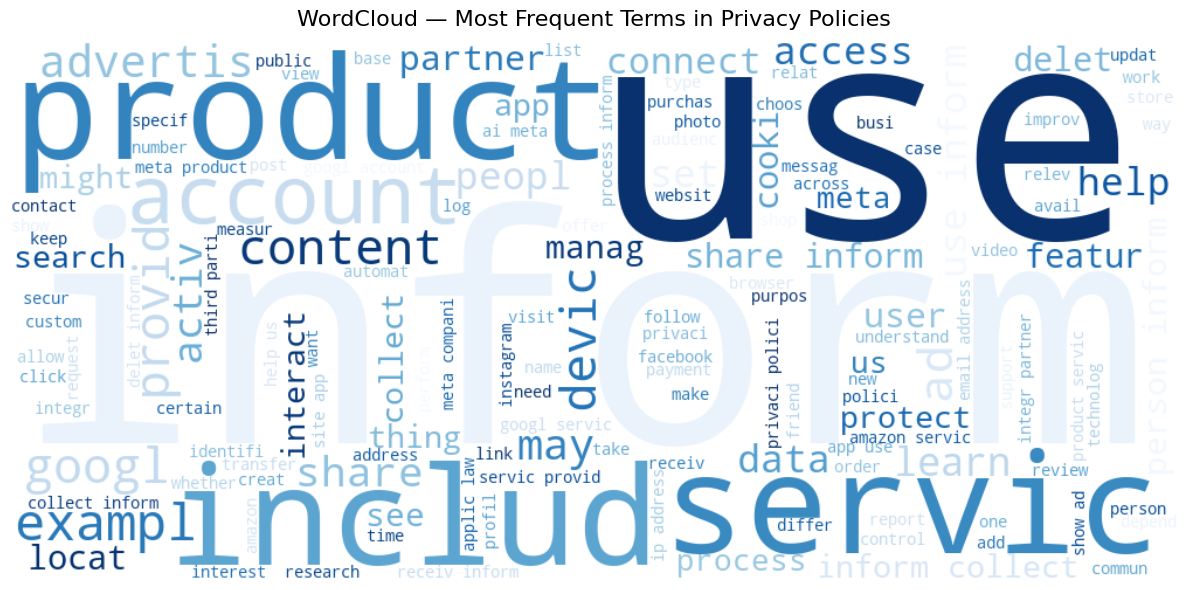

In [11]:
all_text = " ".join(processed_sentences)

wc = WordCloud(width=1000, height=460, background_color='white',
               colormap='Blues', max_words=150).generate(all_text)

plt.figure(figsize=(13, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Most Frequent Terms in Privacy Policies', fontsize=16, pad=12)
plt.tight_layout()
plt.show()

## Step 10 — Inverted Index

An **inverted index** is the data structure behind all search engines and information retrieval systems.
It maps every term to the list of document/clause IDs where it appears:

```
Term (Dictionary)  │ Doc Freq │ Postings List
───────────────────┼──────────┼──────────────────────────
cooki              │   67     │ [12, 47, 83, 201, ...]
track              │   43     │ [15, 22, 67, 310, ...]
share              │   89     │ [8,  31, 44, 177, ...]
locat              │   31     │ [5,  19, 62, 130, ...]
```

**Why it's built on stemmed tokens:**

The index uses the same preprocessed form as the classifier. This means a user typing `cookies` will correctly find clauses containing `cookies`, `cookie`, or `Cookie` — because all three stem to `cooki` and all are indexed under that key.

> Queries are automatically stemmed before lookup — no manual stemming required from the user.

In [12]:
inverted_index = defaultdict(list)

for idx, sent in enumerate(processed_sentences):
    for word in set(sent.split()):
        inverted_index[word].append(idx)

for word in inverted_index:
    inverted_index[word].sort()

print(f"Inverted index built: {len(inverted_index)} unique stemmed terms")
print()

# Formatted postings table
sample_terms = ["cooki", "track", "share", "locat", "advertis"]
col1, col2, col3 = 18, 10, 1
header  = f"{'Term (Dictionary)':<{col1}} │ {'Doc Freq':^{col2}} │ Postings List"
divider = '─' * col1 + '─┼─' + '─' * col2 + '─┼─' + '─' * 30
print(header)
print(divider)
for term in sample_terms:
    p = inverted_index.get(term, [])
    postings_preview = str(p[:4])[:-1] + ', ...]' if len(p) > 4 else str(p)
    print(f"{term:<{col1}} │ {len(p):^{col2}} │ {postings_preview}")

# Stemming demo
print()
demo   = "cookies"
demo_s = stemmer.stem(demo)
hits   = inverted_index.get(demo_s, [])
print(f"Demo: '{demo}' → stemmed '{demo_s}' → {len(hits)} clauses found")


Inverted index built: 1419 unique stemmed terms

Term (Dictionary)  │  Doc Freq  │ Postings List
───────────────────┼────────────┼───────────────────────────────
cooki              │     52     │ [42, 105, 106, 107, ...]
track              │     3      │ [44, 187, 836]
share              │    125     │ [29, 43, 56, 57, ...]
locat              │     45     │ [31, 32, 33, 34, ...]
advertis           │     86     │ [41, 56, 60, 91, ...]

Demo: 'cookies' → stemmed 'cooki' → 52 clauses found


## Step 11 — Keyword Search

How a query is processed:

1. The query is lowercased and each word is **stemmed** (e.g. `cookies` → `cooki`)
2. The stemmed term is looked up in the **inverted index Dictionary**
3. Its **Postings List** gives the matching clause IDs instantly
4. Results show the original clause text, source document, and predicted category

Up to 5 matching clauses are shown per search.

**Try:** `location`, `cookies`, `third party`, `delete`, `advertising`

In [13]:
# Demo query — change this string to try your own keyword
query = "data collection"
# query = input('Enter a keyword to search: ').strip().lower()  # uncomment to run interactively

query = query.strip().lower()
query_tokens = [stemmer.stem(w) for w in word_tokenize(query) if w.isalpha()]

seen  = set()
found = False
print(f"Keyword Search: '{query}'")
print('=' * 50)

for token in query_tokens:
    for i in inverted_index.get(token, []):
        if i in seen: continue
        seen.add(i)
        found = True
        print(f'Clause   : {smart_truncate(sentences[i], 160)}')
        print(f"Source   : {sources[i]}")
        print(f"Category : {predictions[i]}")
        print()
        if len(seen) >= 5: break

if not found:
    print(f"No clauses found for '{query}'.")


Keyword Search: 'data collection'
Clause   : And across our services, you can adjust your privacy settings to control whether we collect some types of data and how we use it.
Source   : google_policy.txt
Category : Data Collection

Clause   : These include: GPS and other sensor data from your device IP address Activity on Google services, such as from your searches or places you label like home or ...
Source   : google_policy.txt
Category : Data Collection

Clause   : We use various technologies to collect and store information, including cookies, pixel tags, local storage, such as browser web storage or application data ...
Source   : google_policy.txt
Category : Data Collection

Clause   : WHY GOOGLE COLLECTS DATA We use data to build better services We use the information we collect from all our services for the following purposes: Provide our ...
Source   : google_policy.txt
Category : Data Collection

Clause   : Go to My Ad Center Measure performance We use data for analytics and 

## Step 12 — Boolean Retrieval Model

### What is the Boolean Retrieval Model?

The **Boolean Retrieval Model** is one of the foundational models in Information Retrieval. It treats documents (or in our case, clauses) as either **relevant or not relevant** to a query — there is no partial match or ranking. A clause either satisfies the logical condition or it does not.

Every query is expressed as a **logical combination of terms** using three operators:

| Operator | Set Operation | What it returns |
|---|---|---|
| `AND` | Intersection `∩` | Clauses containing **all** specified terms |
| `OR` | Union `∪` | Clauses containing **at least one** of the specified terms |
| `NOT` | Difference `\` | Clauses that **do not** contain the specified term |

---

### How it Works with an Inverted Index

Each query term is first stemmed, then its **Postings List** is retrieved from the inverted index. The Boolean operator then determines how those lists are combined:

```
Query: cookies AND tracking

  cooki   → postings: {12, 47, 83, 201, 310}
  track   → postings: {15, 47, 83, 190, 310}
                       ─────────────────────
  AND (∩) →           {47, 83, 310}          ← only IDs in BOTH lists

Query: cookies OR tracking

  cooki   → postings: {12, 47, 83, 201, 310}
  track   → postings: {15, 47, 83, 190, 310}
                       ─────────────────────
  OR  (∪) →           {12, 15, 47, 83, 190, 201, 310}  ← IDs in EITHER list

Query: NOT tracking

  all IDs → postings: {0, 1, 2, ..., 1203}
  track   → postings: {15, 47, 83, 190, 310}
                       ─────────────────────
  NOT (\) →           {0,1,2,...} minus {15,47,83,...}  ← everything EXCEPT track clauses
```

---

### Query Processing Steps

Every Boolean query goes through the same pipeline regardless of operator:

1. **Parse** — split the query string on the operator keyword (`AND`, `OR`, `NOT`)
2. **Stem** — each term is lowercased and stemmed with Porter Stemmer (e.g. `cookies` → `cooki`)
3. **Lookup** — retrieve the Postings List for each stemmed term from the inverted index
4. **Combine** — apply the set operation (intersection / union / difference)
5. **Return** — fetch the original clause text for each matching clause ID

---

### 12a — AND Query

**AND** returns only clauses where every search term appears. This is the most restrictive operator — the result set can only be as large as the smallest individual postings list, and usually much smaller.

**Use AND when** you want clauses that are specifically about multiple topics simultaneously — for example, clauses that discuss both cookies **and** tracking together.

**Try:** `cookies AND tracking`, `share AND third party`, `collect AND location`

In [14]:
# Demo AND query — change this string to try your own
query = "cookies AND tracking"
# query = input('AND query (e.g. cookies AND tracking): ').strip().lower()  # uncomment to run interactively

query = query.strip().lower()
terms = [t.strip() for t in query.split(' and ')]
print(f'AND — clauses containing ALL of: {terms}\n')

term_sets = []
for term in terms:
    tokens  = [stemmer.stem(w) for w in word_tokenize(term) if w.isalpha()]
    indices = None
    for token in tokens:
        hits    = set(inverted_index.get(token, []))
        indices = hits if indices is None else indices & hits
    if indices:
        term_sets.append(indices)

if not term_sets:
    print('No valid terms found.')
else:
    final = set.intersection(*term_sets)
    if not final:
        print('No clauses matched all terms together.')
    else:
        print(f'{len(final)} clause(s) matched:\n')
        for i in sorted(final)[:5]:
            print(f'Clause   : {smart_truncate(sentences[i], 160)}')
            print(f'Source   : {sources[i]}')
            print(f'Category : {predictions[i]}')
            print()


AND — clauses containing ALL of: ['cookies', 'tracking']

No clauses matched all terms together.


### 12b — OR Query

**OR** returns every clause that contains **at least one** of the search terms. This is the most inclusive operator — the result set is the union of all individual postings lists, so it is always at least as large as the largest individual list.

**Use OR when** you want broad coverage of a topic and do not need every term to appear together. For example, searching `advertising OR tracking` will surface all clauses that mention either topic — useful for getting a full picture of how a policy handles data monetization.

**Try:** `advertising OR tracking`, `share OR transfer`, `collect OR gather`

In [15]:
# Demo OR query — change this string to try your own
query = "advertising OR tracking"
# query = input('OR query (e.g. advertising OR tracking): ').strip().lower()  # uncomment to run interactively

query = query.strip().lower()
terms = [t.strip() for t in query.split(' or ')]
print(f'OR — clauses containing ANY of: {terms}\n')

result_set = set()
for term in terms:
    tokens = [stemmer.stem(w) for w in word_tokenize(term) if w.isalpha()]
    for token in tokens:
        result_set.update(inverted_index.get(token, []))

if not result_set:
    print('No clauses found for any of the terms.')
else:
    print(f'{len(result_set)} clause(s) matched:\n')
    for i in sorted(result_set)[:5]:
        print(f'Clause   : {smart_truncate(sentences[i], 160)}')
        print(f'Source   : {sources[i]}')
        print(f'Category : {predictions[i]}')
        print()


OR — clauses containing ANY of: ['advertising', 'tracking']

88 clause(s) matched:

Clause   : We also receive information from partners to provide advertising and research services on their behalf.
Source   : google_policy.txt
Category : Data Collection

Clause   : Maintain & improve our services We also use your information to ensure our services are working as intended, such as tracking outages or troubleshooting issues ...
Source   : google_policy.txt
Category : Tracking

Clause   : We don’t share information that personally identifies you with advertisers, such as your name or email, unless you ask us to.
Source   : google_policy.txt
Category : Data Sharing

Clause   : And we also use data about the ads you interact with, including your related Google Search activity, to help advertisers understand the performance of their ad ...
Source   : google_policy.txt
Category : Advertising

Clause   : You can modify your interests, choose whether your personal information is used to make a

### 12c — NOT Query

**NOT** returns every clause in the corpus that does **not** contain the specified term. It is implemented as a set difference: the full set of all clause IDs minus the postings list of the NOT term.

This is useful for **exclusion filtering** — for example, finding all privacy-related clauses that do not mention cookies, which might reveal data collection practices that are less visible to users.

**Important:** NOT on its own returns a very large result set (almost all clauses). In practice, NOT is most powerful when combined with AND — e.g. `data AND NOT tracking` — to narrow results. This implementation supports standalone NOT as well as `term AND NOT term` patterns.

**Try:** `NOT tracking`, `NOT advertising`, `NOT cookies`

In [16]:
# Demo NOT query — change this string to try your own
query = "data AND NOT tracking"
# query = input('NOT query (e.g. NOT tracking  or  data AND NOT tracking): ').strip().lower()  # uncomment to run interactively

query = query.strip().lower()
all_ids = set(range(len(sentences)))

if ' and not ' in query:
    parts     = query.split(' and not ', 1)
    must_term = parts[0].strip()
    not_term  = parts[1].strip()

    must_tokens = [stemmer.stem(w) for w in word_tokenize(must_term) if w.isalpha()]
    not_tokens  = [stemmer.stem(w) for w in word_tokenize(not_term)  if w.isalpha()]

    must_ids = all_ids.copy()
    for token in must_tokens:
        must_ids &= set(inverted_index.get(token, []))

    not_ids = set()
    for token in not_tokens:
        not_ids |= set(inverted_index.get(token, []))

    final = must_ids - not_ids
    print(f'AND NOT — clauses with "{must_term}" but NOT "{not_term}":\n')

elif query.startswith('not '):
    not_term   = query[4:].strip()
    not_tokens = [stemmer.stem(w) for w in word_tokenize(not_term) if w.isalpha()]
    not_ids    = set()
    for token in not_tokens:
        not_ids |= set(inverted_index.get(token, []))
    final = all_ids - not_ids
    print(f'NOT — clauses that do NOT contain "{not_term}":\n')

else:
    print('Format not recognised. Use: NOT term   or   term AND NOT term')
    final = set()

if final:
    print(f'{len(final)} clause(s) matched (showing first 5):\n')
    for i in sorted(final)[:5]:
        print(f'Clause   : {smart_truncate(sentences[i], 160)}')
        print(f'Source   : {sources[i]}')
        print(f'Category : {predictions[i]}')
        print()
elif not final and query:
    print('No clauses matched.')


AND NOT — clauses with "data" but NOT "tracking":

67 clause(s) matched (showing first 5):

Clause   : And across our services, you can adjust your privacy settings to control whether we collect some types of data and how we use it.
Source   : google_policy.txt
Category : Data Collection

Clause   : These include: GPS and other sensor data from your device IP address Activity on Google services, such as from your searches or places you label like home or ...
Source   : google_policy.txt
Category : Data Collection

Clause   : We use various technologies to collect and store information, including cookies, pixel tags, local storage, such as browser web storage or application data ...
Source   : google_policy.txt
Category : Data Collection

Clause   : WHY GOOGLE COLLECTS DATA We use data to build better services We use the information we collect from all our services for the following purposes: Provide our ...
Source   : google_policy.txt
Category : Data Collection

Clause   : Go to My Ad

## Step 13 — Top-N Important Privacy Clauses

Clauses classified into privacy-sensitive categories (everything except **Other**) are ranked by their **TF-IDF importance score**.

**Why TF-IDF score for ranking?**

A clause with a high mean TF-IDF score contains vocabulary that is:
- Frequent within that clause (high TF), and
- Rare across the rest of the corpus (high IDF)

This means the clause is talking about something specific and substantive — not boilerplate. These are the clauses most worth reading in a long legal document.

> A client uploading a 50-page privacy policy doesn't want to read every sentence. Top-N gives them the 10 most critical clauses immediately.

In [17]:
N = 10

# Normalise clause text using split() — avoids broken regex escaping
results_df['_clause_norm'] = results_df['Clause'].apply(
    lambda x: ' '.join(x.lower().split())
)
# 100-char prefix key: catches near-duplicate clauses with same opening
results_df['_clause_prefix'] = results_df['_clause_norm'].str[:100]

important_df = (
    results_df[results_df["Category"] != "Other"]
    .drop_duplicates(subset="_clause_prefix")
    .sort_values("TF_IDF_Score", ascending=False)
    .reset_index(drop=True)
)

print(f"Top {N} Most Important Privacy Clauses (ranked by TF-IDF score):")
print("=" * 68)

for rank, row in important_df.head(N).iterrows():
    print(f"\n#{rank+1}  [{row['Category']}]  {row['Risk_Flag']}  TF-IDF: {row['TF_IDF_Score']:.5f}")
    print(f"    Source : {row['Source']}")
    print(f"    Clause : {smart_truncate(row['Clause'], 150)}")


Top 10 Most Important Privacy Clauses (ranked by TF-IDF score):

#1  [Data Collection]  🟠 LOW RISK  TF-IDF: 0.00413
    Source : amazon_policy.txt
    Clause : Back to Top Related Practices and Information Conditions of Use Seller Program Policies Help Department Most Recent Purchases Your Profile and ...

#2  [Data Sharing]  🔴 HIGH RISK  TF-IDF: 0.00385
    Source : instagram_policy.txt
    Clause : Investigating suspicious activity Protecting ourselves, including our rights, property, personnel or Products Preventing abuse, fraud or other ...

#3  [Data Collection]  🟠 LOW RISK  TF-IDF: 0.00362
    Source : amazon_policy.txt
    Clause : Automatic Information Examples of the information we collect and analyze include: the internet protocol (IP) address used to connect your computer to ...

#4  [Data Sharing]  🔴 HIGH RISK  TF-IDF: 0.00360
    Source : instagram_policy.txt
    Clause : 68 How long we need to retain the information to comply with certain legal obligations For example, we

## Step 14 — Privacy Category Distribution

Two charts showing how clauses are distributed across privacy categories:

- **Left chart:** overall distribution across all documents combined (excluding Other)
- **Right chart:** per-document stacked breakdown — compare how different organizations handle each category

**What to look for:**

| High count in... | What it signals |
|---|---|
| Data Sharing | User data is frequently transferred to third parties |
| Tracking | Policy heavily discusses cookies and behaviour monitoring |
| Location Data | Sensitive — physical whereabouts are being collected or shared |
| Advertising | Personal data is commercially exploited for targeting |

Overall Privacy Category Distribution:
Category
Other              433
Data Collection    275
Data Sharing       150
Advertising        107
Tracking            61
Location Data       22


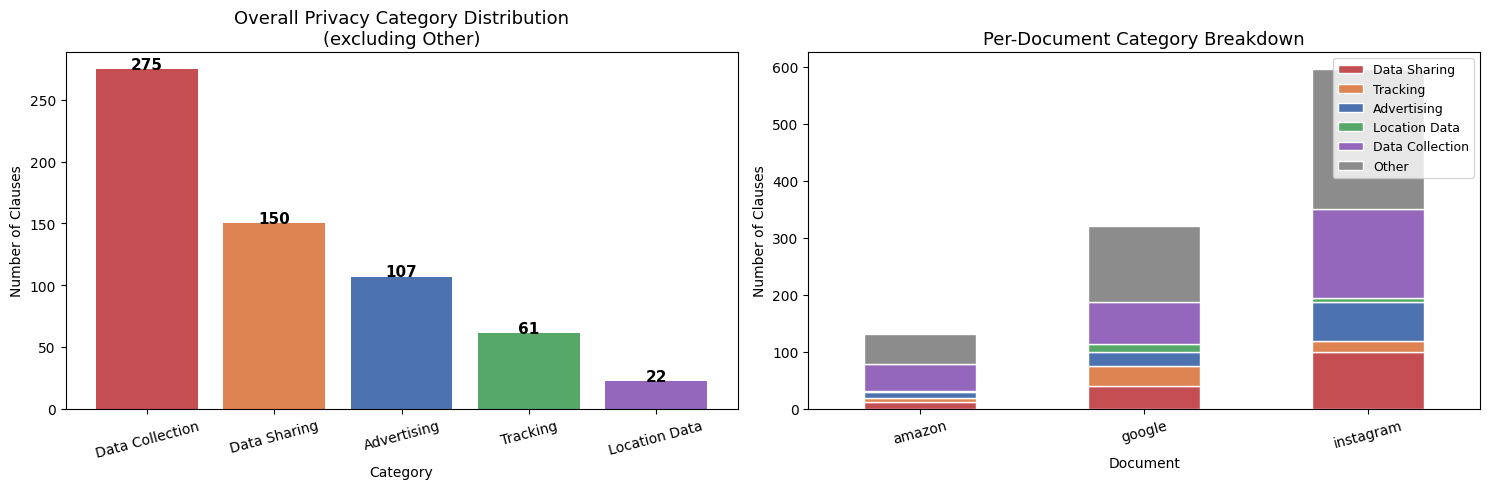

In [18]:
print("Overall Privacy Category Distribution:")
category_counts = results_df['Category'].value_counts()
print(category_counts.to_string())

privacy_cats = category_counts.drop('Other', errors='ignore')
colors = ['#C44E52','#DD8452','#4C72B0','#55A868','#9467BD','#8C8C8C']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: overall bar chart
bars = axes[0].bar(privacy_cats.index, privacy_cats.values,
                   color=colors[:len(privacy_cats)])
axes[0].set_title('Overall Privacy Category Distribution\n(excluding Other)', fontsize=13)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Clauses')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, privacy_cats.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3, str(val),
                 ha='center', fontweight='bold', fontsize=11)

# Right: per-document stacked bar
cat_order = list(RISK_WEIGHTS.keys())
pivot = pd.crosstab(results_df['Source'], results_df['Category'])
for cat in cat_order:
    if cat not in pivot.columns: pivot[cat] = 0
pivot = pivot[[c for c in cat_order if c in pivot.columns]]
pivot.plot(kind='bar', stacked=True, ax=axes[1],
           color=colors[:len(pivot.columns)], edgecolor='white')
axes[1].set_title('Per-Document Category Breakdown', fontsize=13)
axes[1].set_xlabel('Document')
axes[1].set_ylabel('Number of Clauses')
axes[1].set_xticklabels(
    [f.replace('_policy.txt','').replace('_',' ') for f in pivot.index], rotation=15)
axes[1].legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## Step 15 — Readability Analysis

Privacy policies are notoriously difficult to read. This section quantifies that per document and overall.

**Metrics measured:**

| Metric | What it captures |
|---|---|
| Average sentence length (words) | Longer sentences are harder to parse |
| Average word length (characters) | Longer words indicate more technical or legal vocabulary |
| Readability level | Classification based on sentence length |

**Readability thresholds:**

| Average sentence length | Level |
|---|---|
| > 25 words | 🔴 Difficult |
| 15 – 25 words | 🟡 Moderate |
| < 15 words | 🟢 Easy |

In [19]:
print('Readability Analysis')
print('=' * 55)

all_sent_lens = []
all_word_lens = []

for doc_file in files:
    doc_sents = [s for s, src in zip(sentences, sources) if src == doc_file]
    sent_lens = [len(word_tokenize(s)) for s in doc_sents]
    word_lens = [len(w) for s in doc_sents for w in word_tokenize(s) if w.isalpha()]
    avg_sent  = np.mean(sent_lens)
    avg_word  = np.mean(word_lens)
    level     = 'Difficult' if avg_sent > 25 else 'Moderate' if avg_sent > 15 else 'Easy'
    all_sent_lens.extend(sent_lens)
    all_word_lens.extend(word_lens)
    print(f"\n  {doc_file}")
    print(f"    Average sentence length : {avg_sent:.1f} words  →  {level}")
    print(f"    Average word length     : {avg_word:.1f} characters")

overall_sent = np.mean(all_sent_lens)
overall_word = np.mean(all_word_lens)
overall_lvl  = 'Difficult' if overall_sent > 25 else 'Moderate' if overall_sent > 15 else 'Easy'
print(f"\n  OVERALL")
print(f"    Average sentence length : {overall_sent:.1f} words  →  {overall_lvl}")
print(f"    Average word length     : {overall_word:.1f} characters")

Readability Analysis

  google_policy.txt
    Average sentence length : 29.5 words  →  Difficult
    Average word length     : 5.0 characters

  amazon_policy.txt
    Average sentence length : 31.3 words  →  Difficult
    Average word length     : 5.4 characters

  instagram_policy.txt
    Average sentence length : 30.3 words  →  Difficult
    Average word length     : 5.0 characters

  OVERALL
    Average sentence length : 30.2 words  →  Difficult
    Average word length     : 5.0 characters


## Step 16 — Model Evaluation

The best-performing model (auto-selected in Step 6) is evaluated in full on the **held-out 20% test set**.

**Evaluation metrics:**

| Metric | Formula | What it tells you |
|---|---|---|
| **Precision** | TP ÷ (TP + FP) | Of all clauses predicted as category X, how many actually are X |
| **Recall** | TP ÷ (TP + FN) | Of all true X clauses, how many did the model correctly find |
| **F1 Score** | 2·P·R ÷ (P+R) | Harmonic mean of precision and recall — the balanced measure |
| **Accuracy** | Correct ÷ Total | Overall proportion of correct predictions on the test set |

> Evaluating on held-out data (not training data) is essential. A model that memorizes training examples would score 100% on training data but fail on new clauses. The test set measures true generalization.

**Why the pipeline was improved over a baseline Multinomial NB:**

| Improvement | Effect |
|---|---|
| Bigrams in TF-IDF `(1,2)` | `third_parti`, `data_collect` are far more discriminative than individual words |
| `min_df=2, max_df=0.95` | Removes single-occurrence noise and ultra-common uninformative terms |
| `sublinear_tf=True` | Long clauses no longer dominate — fairer feature weighting |
| Cleaner keyword set | Removed `access`, `activ`, `parti` — too generic, caused label noise |
| Model comparison | Best of 4 classifiers auto-selected — not committed to one upfront |

> **Note on accuracy:** Labels are generated by keyword matching (Step 6), so high accuracy reflects the model successfully learning those keyword patterns — not overfitting or data leakage.

**5-Fold Cross-Validation** is also run on the best model to give a more reliable accuracy estimate than a single train/test split.

| Why k-fold CV matters | |
|---|---|
| Single split accuracy depends on which clauses ended up in test | CV averages across 5 different splits — more stable estimate |
| Reports mean ± std deviation | Shows how consistent the model is across different data subsets |


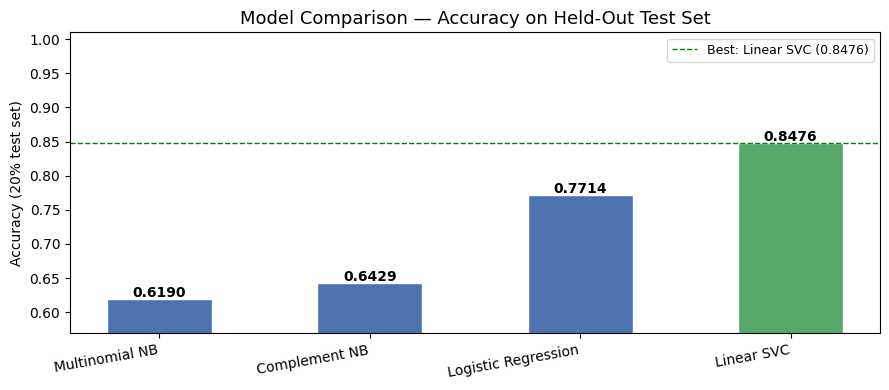


Best Model: Linear SVC
Accuracy : 0.8476

Classification Report:
                 precision    recall  f1-score   support

    Advertising       0.90      0.82      0.86        22
Data Collection       0.96      0.82      0.89        57
   Data Sharing       0.86      0.77      0.81        31
  Location Data       1.00      0.40      0.57         5
          Other       0.78      0.98      0.86        82
       Tracking       0.88      0.54      0.67        13

       accuracy                           0.85       210
      macro avg       0.89      0.72      0.78       210
   weighted avg       0.86      0.85      0.84       210


5-Fold Cross-Validation (best model on full dataset):
---------------------------------------------
  Fold scores : [np.float64(0.8), np.float64(0.819), np.float64(0.8381), np.float64(0.823), np.float64(0.7895)]
  Mean        : 0.8139
  Std dev     : 0.0172
  95% CI      : [0.7795, 0.8484]


In [20]:
# ── Model comparison bar chart ───────────────────────────────────────────────
model_names  = list(model_results.keys())
model_accs   = [model_results[n]['accuracy'] for n in model_names]
bar_colors   = ['#55A868' if n == best_name else '#4C72B0' for n in model_names]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(model_names, model_accs, color=bar_colors, edgecolor='white', width=0.5)
ax.set_ylim(min(model_accs) - 0.05, 1.01)
ax.set_ylabel('Accuracy (20% test set)')
ax.set_title('Model Comparison — Accuracy on Held-Out Test Set', fontsize=13)
for bar, acc in zip(bars, model_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{acc:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(y=max(model_accs), color='green', linestyle='--', linewidth=1,
           label=f'Best: {best_name} ({max(model_accs):.4f})')
ax.legend(fontsize=9)
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.show()

# ── Best model full classification report ────────────────────────────────────
print(f'\nBest Model: {best_name}')
print('=' * 52)
print(f'Accuracy : {model_results[best_name]["accuracy"]:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

# ── 5-Fold Cross-Validation on best model ────────────────────────────────────
print('\n5-Fold Cross-Validation (best model on full dataset):')
print('-' * 45)
cv_scores = cross_val_score(model, X, labels, cv=5, scoring='accuracy')
print(f'  Fold scores : {[round(s,4) for s in cv_scores]}')
print(f'  Mean        : {cv_scores.mean():.4f}')
print(f'  Std dev     : {cv_scores.std():.4f}')
print(f'  95% CI      : [{cv_scores.mean()-2*cv_scores.std():.4f},'
      f' {cv_scores.mean()+2*cv_scores.std():.4f}]')


### Confusion Matrix

The **confusion matrix** shows exactly where the model succeeds and where it makes mistakes — class by class.

Each row is the **actual** category; each column is what the model **predicted**.
A perfect model has all counts on the diagonal and zeros everywhere else.

| Reading the matrix | What it tells you |
|---|---|
| High diagonal values | Model correctly identifies this category |
| Off-diagonal values | Model confused one category for another |
| Large off-diagonal in a row | That category is hardest to classify |

Two confusion matrices are shown:
- **Left** — the best-performing model (auto-selected above)
- **Right** — Multinomial NB (baseline), shown regardless of rank so you can see what the improvement looks like visually

> The difference between the two matrices shows exactly which categories the better model fixed.


Confusion Matrix — Linear SVC (Best Model):
                 Advertising  Data Collection  Data Sharing  Location Data  Other  Tracking
Advertising               18                0             0              0      4         0
Data Collection            0               47             3              0      6         1
Data Sharing               0                0            24              0      7         0
Location Data              0                0             1              2      2         0
Other                      1                1             0              0     80         0
Tracking                   1                1             0              0      4         7

Confusion Matrix — Multinomial NB (Baseline):
                 Advertising  Data Collection  Data Sharing  Location Data  Other  Tracking
Advertising                4                4             0              0     14         0
Data Collection            0               43             1              0     13

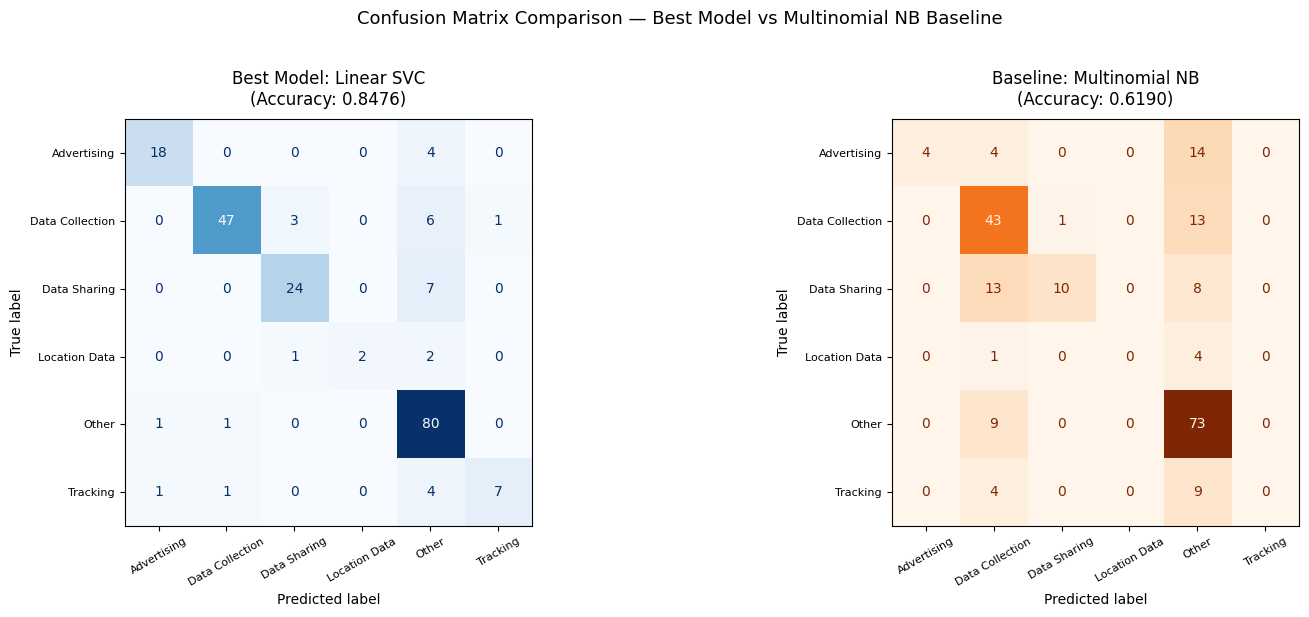


Improvement over Multinomial NB baseline: +0.2286 accuracy


In [21]:
cm_labels_all = sorted(set(y_test))

# Best model confusion matrix
cm_best = confusion_matrix(y_test, y_pred, labels=cm_labels_all)

# MultinomialNB confusion matrix — always shown as baseline
mnb_pred = model_results['Multinomial NB']['y_pred']
cm_mnb   = confusion_matrix(y_test, mnb_pred, labels=cm_labels_all)

# Printed tables
print(f'Confusion Matrix — {best_name} (Best Model):')
print(pd.DataFrame(cm_best, index=cm_labels_all, columns=cm_labels_all).to_string())
print()
print('Confusion Matrix — Multinomial NB (Baseline):')
print(pd.DataFrame(cm_mnb, index=cm_labels_all, columns=cm_labels_all).to_string())

# Side-by-side visual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm_best, display_labels=cm_labels_all
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Best Model: {best_name}\n(Accuracy: {model_results[best_name]["accuracy"]:.4f})',
                  fontsize=12, pad=10)
axes[0].tick_params(axis='x', rotation=30, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

ConfusionMatrixDisplay(
    confusion_matrix=cm_mnb, display_labels=cm_labels_all
).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Baseline: Multinomial NB\n(Accuracy: {model_results["Multinomial NB"]["accuracy"]:.4f})',
                  fontsize=12, pad=10)
axes[1].tick_params(axis='x', rotation=30, labelsize=8)
axes[1].tick_params(axis='y', labelsize=8)

plt.suptitle('Confusion Matrix Comparison — Best Model vs Multinomial NB Baseline',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nImprovement over Multinomial NB baseline: '
      f'+{(model_results[best_name]["accuracy"] - model_results["Multinomial NB"]["accuracy"]):.4f} accuracy')


## Step 17 — Full Analysis Summary

A single consolidated view of everything the analyzer found.

This is what a client expects to see after uploading their privacy policy — all findings in one place without needing to scroll through individual cells:

- How many documents and clauses were analyzed
- Risk score and label for each document
- Overall corpus risk
- Category distribution at a glance
- Readability verdict
- Model accuracy
- Top 5 most important privacy clauses

In [22]:
print('\n' + '#'*65)
print('  PRIVACY POLICY RISK ANALYZER — FULL SUMMARY')
print('#'*65)

print(f'\n  Documents analyzed : {len(files)}')
print(f'  Total clauses      : {len(sentences)}')

print('\n  --- RISK SCORES PER DOCUMENT ---')
for row in risk_summary:
    bar = '#' * min(row['Risk Score'] // 3, 40)
    print(f"  {row['Document']:<35} {row['Risk Level']:6}  score={row['Risk Score']}  density={row['Density']}  {bar}")
print(f'\n  Overall corpus risk : {global_level}  (score: {global_score}  density: {global_density})')

print('\n  --- PER-CLAUSE RISK FLAG SUMMARY ---')
for flag, cnt in results_df['Risk_Flag'].value_counts().items():
    bar = '|' * min(cnt // 10, 45)
    print(f'  {flag:<22} {cnt:5}  {bar}')

print('\n  --- CATEGORY DISTRIBUTION ---')
for cat, cnt in results_df['Category'].value_counts().items():
    bar = '|' * min(cnt // 10, 45)
    print(f'  {cat:<22} {cnt:5}  {bar}')

print('\n  --- READABILITY ---')
print(f'  Overall: {overall_sent:.1f} words/sentence  →  {overall_lvl}')

print('\n  --- MODEL ACCURACY ---')
print(f'  {accuracy_score(y_test, y_pred):.2%} on {len(y_test)} held-out clauses')

print('\n  --- TOP 5 MOST IMPORTANT PRIVACY CLAUSES ---')
for rank, row in important_df.head(5).iterrows():
    print(f"  #{rank+1} [{row['Category']}] {row['Risk_Flag']}")
    print(f"      Source : {row['Source']}")
    print(f"      Clause : {smart_truncate(row['Clause'], 150)}")
    print()
print('#'*65)
print('\n  ✅ Run Step 19 to export a shareable HTML report.')



#################################################################
  PRIVACY POLICY RISK ANALYZER — FULL SUMMARY
#################################################################

  Documents analyzed : 3
  Total clauses      : 1048

  --- RISK SCORES PER DOCUMENT ---
  google_policy.txt                   HIGH    score=375  density=116.8  ########################################
  amazon_policy.txt                   HIGH    score=127  density=96.9  ########################################
  instagram_policy.txt                HIGH    score=664  density=111.4  ########################################

  Overall corpus risk : HIGH  (score: 1166  density: 111.3)

  --- PER-CLAUSE RISK FLAG SUMMARY ---
  ✅ OK                     433  |||||||||||||||||||||||||||||||||||||||||||
  🟠 LOW RISK               275  |||||||||||||||||||||||||||
  🔴 HIGH RISK              211  |||||||||||||||||||||
  🟡 MEDIUM RISK            129  ||||||||||||

  --- CATEGORY DISTRIBUTION ---
  Other                 

## Step 18 — Industry Benchmark Comparison

Raw risk scores grow with document length — a 700-clause policy will always outscore a 130-clause one even if it's proportionally less risky. To make a fair comparison, we use **risk density**: risk score per 100 clauses.

Since we analyzed Google, Amazon, and Instagram, these three form our **industry benchmark**. Any policy you add to the `files` list will automatically be compared against them.

| Benchmark tier | Risk Density | Meaning |
|---|---|---|
| Below average | < corpus average | Less aggressive data practices than peers |
| Average | ≈ corpus average | Typical for large tech companies |
| Above average | > corpus average | More aggressive than peers — warrants closer reading |


  INDUSTRY BENCHMARK — Risk Density (score per 100 clauses)
  Corpus average density : 108.4

  google_policy.txt                   density=116.8  🟡 Average         — typical for big tech
                                      ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

  amazon_policy.txt                   density= 96.9  🟢 Below average  — relatively low risk
                                      ████████████████████████████████████████████████████████████████████████████████████████████████

  instagram_policy.txt                density=111.4  🟡 Average         — typical for big tech
                                      ███████████████████████████████████████████████████████████████████████████████████████████████████████████████



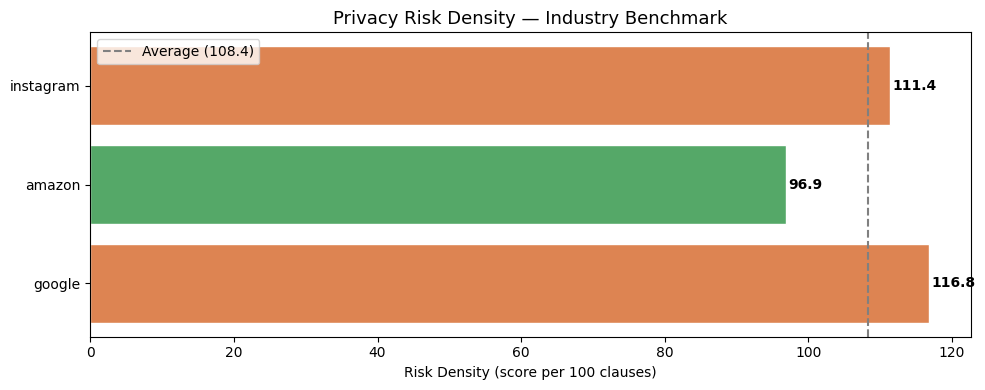

In [23]:
# Build benchmark from all analyzed documents
bench_df = pd.DataFrame(risk_summary)
avg_density = bench_df['Density'].mean()

print('=' * 65)
print('  INDUSTRY BENCHMARK — Risk Density (score per 100 clauses)')
print('=' * 65)
print(f'  Corpus average density : {avg_density:.1f}\n')

for _, row in bench_df.iterrows():
    d = row['Density']
    if d < avg_density * 0.9:
        verdict = '🟢 Below average  — relatively low risk'
    elif d <= avg_density * 1.1:
        verdict = '🟡 Average         — typical for big tech'
    else:
        verdict = '🔴 Above average  — more aggressive than peers'
    bar = '█' * int(d)
    print(f"  {row['Document']:<35} density={d:5.1f}  {verdict}")
    print(f"  {'':35} {bar}")
    print()

# Chart
fig, ax = plt.subplots(figsize=(10, 4))
colors_bench = ['#C44E52' if d > avg_density*1.1 else '#DD8452' if d >= avg_density*0.9 else '#55A868'
                for d in bench_df['Density']]
bars = ax.barh(bench_df['Document'].str.replace('_policy.txt','').str.replace('_',' '),
               bench_df['Density'], color=colors_bench, edgecolor='white')
ax.axvline(avg_density, color='gray', linestyle='--', linewidth=1.5, label=f'Average ({avg_density:.1f})')
for bar, val in zip(bars, bench_df['Density']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontweight='bold')
ax.set_xlabel('Risk Density (score per 100 clauses)')
ax.set_title('Privacy Risk Density — Industry Benchmark', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


## Step 19 — Export Summary Report

Generates a self-contained **HTML report** you can open in any browser, share with anyone, or print to PDF.

The report includes:
- Document risk scores and per-clause breakdown
- Industry benchmark comparison
- Top 10 highest-risk clauses with full text
- Readability verdict
- Model accuracy

> **To save as PDF:** open the generated HTML file in Chrome/Edge → File → Print → Save as PDF.


In [24]:
from datetime import datetime

def risk_color(level):
    return {'HIGH':'#C44E52','MEDIUM':'#DD8452','LOW':'#55A868'}.get(level,'#888')

def flag_color(flag):
    if '🔴' in flag: return '#fde8e8'
    if '🟡' in flag: return '#fff4e0'
    if '🟠' in flag: return '#fff8e0'
    return '#f0faf0'

# Build per-doc risk rows
doc_rows = ''
for row in risk_summary:
    col = risk_color(row['Risk Level'])
    doc_rows += f"""
    <tr>
      <td><b>{row['Document']}</b></td>
      <td>{row['Clauses']}</td>
      <td>{row['Risk Score']}</td>
      <td>{row['Density']}</td>
      <td style='color:{col};font-weight:bold'>{row['Risk Level']}</td>
      <td>{row['🔴 High']}</td>
      <td>{row['🟡 Medium']}</td>
    </tr>"""

# Top 10 risky clauses — use prefix key computed in Step 13
top_risky = (
    results_df[results_df['Risk_Flag'] != '✅ OK']
    .drop_duplicates(subset='_clause_prefix')
    .sort_values('TF_IDF_Score', ascending=False)
    .head(10)
)
clause_rows = ''
for _, r in top_risky.iterrows():
    bg = flag_color(r['Risk_Flag'])
    clause_rows += f"""
    <tr style='background:{bg}'>
      <td>{r['Risk_Flag']}</td>
      <td>{r['Category']}</td>
      <td style='font-size:0.85em'>{r['Source']}</td>
      <td style='font-size:0.85em'>{smart_truncate(r['Clause'], 200)}</td>
    </tr>"""

# Benchmark rows
bench_rows = ''
for _, row in bench_df.iterrows():
    d = row['Density']
    if d < avg_density * 0.9: verdict = '🟢 Below average'
    elif d <= avg_density * 1.1: verdict = '🟡 Average'
    else: verdict = '🔴 Above average'
    pct = min(int(d / (avg_density * 2) * 100), 100)
    bar_html = f"<div style='background:#4C72B0;height:14px;width:{pct}%;border-radius:4px'></div>"
    bench_rows += f"<tr><td>{row['Document']}</td><td>{d}</td><td>{bar_html}</td><td>{verdict}</td></tr>"

html = f"""
<!DOCTYPE html><html><head>
<meta charset='UTF-8'>
<title>Privacy Policy Risk Report</title>
<style>
  body{{font-family:Arial,sans-serif;max-width:960px;margin:40px auto;color:#222;line-height:1.6}}
  h1{{background:#2c3e50;color:white;padding:20px 28px;border-radius:8px;margin-bottom:6px}}
  h2{{border-left:5px solid #4C72B0;padding-left:12px;margin-top:36px;color:#2c3e50}}
  table{{border-collapse:collapse;width:100%;margin-top:12px;font-size:0.9em}}
  th{{background:#4C72B0;color:white;padding:10px 12px;text-align:left}}
  td{{padding:9px 12px;border-bottom:1px solid #eee}}
  tr:hover td{{background:#f5f8ff}}
  .meta{{color:#666;font-size:0.9em;margin-bottom:28px}}
  .pill{{display:inline-block;padding:3px 10px;border-radius:12px;font-weight:bold;font-size:0.85em}}
  .stat-grid{{display:grid;grid-template-columns:repeat(4,1fr);gap:16px;margin:20px 0}}
  .stat{{background:#f7f9fc;border:1px solid #dde3ed;border-radius:8px;padding:16px;text-align:center}}
  .stat .val{{font-size:2em;font-weight:bold;color:#2c3e50}}
  .stat .lbl{{font-size:0.8em;color:#666;margin-top:4px}}
  .footer{{margin-top:48px;padding-top:16px;border-top:1px solid #ddd;color:#999;font-size:0.8em;text-align:center}}
</style></head><body>
<h1>🔍 Privacy Policy Risk Analyzer</h1>
<p class='meta'>Generated: {datetime.now().strftime('%d %B %Y, %H:%M')} &nbsp;|&nbsp; Documents: {len(files)} &nbsp;|&nbsp; Total clauses: {len(sentences)}</p>

<div class='stat-grid'>
  <div class='stat'><div class='val'>{len(files)}</div><div class='lbl'>Documents</div></div>
  <div class='stat'><div class='val'>{len(sentences)}</div><div class='lbl'>Clauses</div></div>
  <div class='stat'><div class='val' style='color:{risk_color(global_level)}'>{global_level}</div><div class='lbl'>Overall Risk</div></div>
  <div class='stat'><div class='val'>{accuracy_score(y_test, y_pred):.0%}</div><div class='lbl'>Model Accuracy</div></div>
</div>

<h2>📄 Risk Score per Document</h2>
<table><tr><th>Document</th><th>Clauses</th><th>Score</th><th>Density</th><th>Level</th><th>🔴 High Risk</th><th>🟡 Med Risk</th></tr>
{doc_rows}</table>

<h2>📊 Industry Benchmark (Risk Density)</h2>
<p>Risk density = score per 100 clauses — normalises for document length. Corpus average: <b>{avg_density:.1f}</b></p>
<table><tr><th>Document</th><th>Density</th><th>Bar</th><th>Verdict</th></tr>{bench_rows}</table>

<h2>⚠️ Top 10 Highest-Risk Clauses</h2>
<table><tr><th>Flag</th><th>Category</th><th>Source</th><th>Clause</th></tr>
{clause_rows}</table>

<h2>📖 Readability</h2>
<p>Overall average sentence length: <b>{overall_sent:.1f} words</b> — verdict: <b>{overall_lvl}</b><br>
Average word length: <b>{overall_word:.1f} characters</b></p>

<h2>🤖 Model Accuracy</h2>
<p>Multinomial Naive Bayes accuracy on 20% held-out test set: <b>{accuracy_score(y_test, y_pred):.2%}</b></p>

<div class='footer'>Generated by Privacy Policy Risk Analyzer — FDS DA2</div>
</body></html>
"""

report_path = 'privacy_risk_report.html'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(html)

print(f'✅ Report saved to: {report_path}')
print(f'   Open this file in any browser to view the full report.')
print(f'   To save as PDF: Chrome → File → Print → Save as PDF')


✅ Report saved to: privacy_risk_report.html
   Open this file in any browser to view the full report.
   To save as PDF: Chrome → File → Print → Save as PDF


## Conclusion

This notebook implements a complete end-to-end text mining and NLP pipeline for privacy policy analysis.

**Pipeline summary:**

| Step | Technique | Purpose |
|---|---|---|
| Text cleaning | Lowercase → tokenize → stopword removal → Porter stemming | Normalize text for consistent feature extraction |
| TF-IDF | `TfidfVectorizer` | Convert clauses to numerical feature vectors |
| Term-Document Matrix | TF-IDF weight matrix | Numerical representation of the corpus |
| Category labeling | Stemmed keyword matching | Generate training labels without pre-labeled data |
| Model Comparison | MultinomialNB, ComplementNB, Logistic Regression, Linear SVC | Auto-select best classifier on held-out test set |
| Cross-Validation | 5-fold CV on best model | Reliable accuracy estimate with mean ± std |
| Inverted Index | Postings list per stemmed term | Enable fast clause retrieval |
| Keyword search | Stemmed query → postings lookup | Find relevant clauses instantly |
| Boolean AND | Set intersection of postings lists | Clauses containing all specified terms |
| Boolean OR | Set union of postings lists | Clauses containing any specified term |
| Boolean NOT | Set difference from full clause set | Clauses excluding a specified term |
| Risk scoring | Weighted category counts per document | Quantify privacy risk as HIGH / MEDIUM / LOW |
| Visualization | WordCloud + bar charts | Communicate findings visually |
| Readability | Avg sentence/word length | Measure how accessible the policy is |
| Evaluation | Precision, Recall, F1, Accuracy on test set | Measure how well the model generalizes |
| Confusion Matrix | `ConfusionMatrixDisplay` heatmap | Show per-class prediction accuracy and misclassifications |
| Per-clause Risk Flag | `CLAUSE_RISK_FLAG` dict | Flag each clause as 🔴 HIGH / 🟡 MEDIUM / 🟠 LOW / ✅ OK |
| Benchmark Comparison | Risk density normalization | Compare policies fairly regardless of document length |
| HTML Report Export | Jinja-style f-string HTML | Produce a shareable, browser-viewable report |

---

## Possible Extensions

The following extensions would take this tool from a university project to a production-grade privacy policy analyzer:

### 🧠 Smarter NLP

| Extension | What it adds |
|---|---|
| **AI-powered clause summarizer** | Call an LLM API (e.g. Claude / GPT) per clause to rewrite legal text into one plain-English sentence — *"Amazon shares your data with third-party vendors"* instead of the raw legal clause |
| **Sentence transformer embeddings** | Replace TF-IDF with `sentence-transformers` (BERT-based) — captures semantic meaning, not just keyword overlap. *"We gather information"* and *"data is collected"* would score as similar |
| **Named Entity Recognition (NER)** | Use spaCy NER to flag company names, countries, and data types mentioned in clauses — *"shared with Google Analytics in the USA"* |
| **Sentiment analysis per clause** | Detect whether a clause is user-friendly or adversarial in tone using a fine-tuned sentiment model |
| **Topic modeling (LDA)** | Discover latent topics across the corpus without any keyword rules — fully unsupervised alternative to the current labeling approach |

### ⚖️ Compliance & Legal

| Extension | What it adds |
|---|---|
| **GDPR compliance checker** | Match clauses against a checklist of GDPR requirements (right to erasure, data minimization, lawful basis) and flag which are missing |
| **CCPA compliance checker** | Same for California Consumer Privacy Act — flag whether the policy discloses sale of data, opt-out rights, and data categories |
| **Regulatory diff tool** | Compare two versions of the same policy (e.g. old vs new) and highlight what changed — useful for tracking policy updates over time |
| **Data retention clause detector** | Specifically extract how long each data type is retained and flag unusually long or unspecified periods |

### 📊 Better Analysis

| Extension | What it adds |
|---|---|
| **Cross-policy similarity scoring** | Use cosine similarity on TF-IDF or embeddings to measure how similar two policies are — useful for detecting copy-pasted boilerplate |
| **Risk trend over time** | If multiple versions of a policy are provided, plot how risk score changed across versions |
| **Per-user-type risk scoring** | Separate risk scores for children, EU users, California users — different clauses are more or less relevant depending on who is reading |
| **Flesch-Kincaid readability score** | Replace the current word-length heuristic with the standard FK readability formula used in legal research |

### 🖥️ Product & UX

| Extension | What it adds |
|---|---|
| **Browser extension** | Automatically analyze the privacy policy of any website you visit and show a risk badge in the toolbar |
| **PDF batch upload** | Accept PDF files directly using `pdfplumber` — no manual `.txt` conversion needed |
| **Interactive web app** | Wrap the pipeline in a `Streamlit` or `Gradio` app — drag and drop a policy, get a full report in the browser |
| **Multilingual support** | Use `langdetect` + multilingual sentence transformers to analyze policies in French, German, Spanish, etc. |
| **Email alert system** | Periodically fetch a company's live policy URL, re-run analysis, and email the user if the risk score increases significantly |
